In [1]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
kaggle_dataset_df = df = pd.read_csv('../data/mountain_dataset.csv', converters={'marker': eval})
synthetic_dataset_df = pd.read_csv('../data/synthetic_dataset.csv', converters={'marker': eval})

In [5]:
final_dataset_df = pd.concat([kaggle_dataset_df, synthetic_dataset_df], ignore_index=True)

In [6]:
final_dataset_df

,text,marker
0,A visit to a science museum for hands-on learn...,[]
1,Voice surface coach set democratic time year. ...,[]
2,Parent according maybe activity activity finis...,[]
3,A visit to a sculpture garden with intriguing ...,[]
4,The Julian Alps in Slovenia offer pristine lak...,"[(11, 15)]"
...,...,...
2586,A view of Mount Kenya made the long drive wort...,"[[10, 21]]"
2587,"The Black Forest isn't a mountain range, but t...","[[56, 61]]"
2588,Yesterday we visited the Eiger and the Jungfra...,"[[25, 30], [39, 47]]"
2589,The Pennine Alps are part of the broader Alpin...,"[[4, 16]]"


In [8]:
def split_markers(text, markers):
    splitted_markers = []
    
    for start, end in markers:
        
        # Extract the mountain name
        mountain_name = text[start:end]

        # Split the mountain name into individual words
        words = mountain_name.split(" ")

        # Generate separate marker for each word
        for word in words:
            word_start = text.find(word, start)
            word_end = word_start + len(word)
            splitted_markers.append((word_start, word_end))

    
    return splitted_markers


final_dataset_df['markers'] = final_dataset_df.apply(lambda row: split_markers(row['text'], row['marker']), axis=1)

In [9]:
final_dataset_df.head()

,text,marker,markers
0,A visit to a science museum for hands-on learn...,[],[]
1,Voice surface coach set democratic time year. ...,[],[]
2,Parent according maybe activity activity finis...,[],[]
3,A visit to a sculpture garden with intriguing ...,[],[]
4,The Julian Alps in Slovenia offer pristine lak...,"[(11, 15)]","[(11, 15)]"


In [10]:
final_dataset_df['mountain_count'] = final_dataset_df['markers'].apply(len)
final_dataset_df['mountain_count'].value_counts(normalize=True)

mountain_count
0    0.524508
2    0.325357
1    0.096874
3    0.032420
4    0.016982
5    0.003474
8    0.000386
Name: proportion, dtype: float64

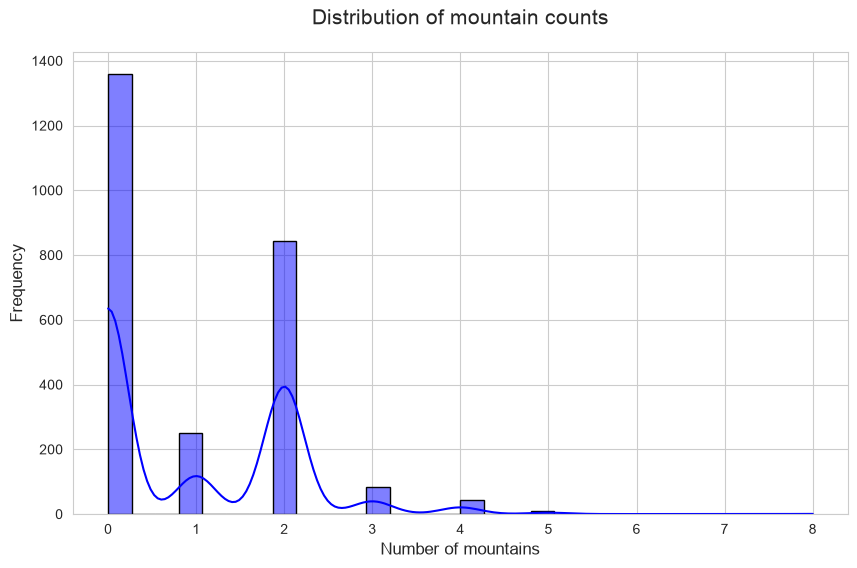

In [11]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(final_dataset_df['mountain_count'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of mountain counts", fontsize=15, pad=20)
plt.xlabel("Number of mountains", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

In [12]:
def get_mountains(row):
    text, loc_markers = row['text'], row['markers']
    return [text[i:j] for i, j in loc_markers]

In [20]:
mountain_record = final_dataset_df[final_dataset_df['mountain_count'] >= 1].iloc[22]
print(mountain_record.text)

mountains = get_mountains(mountain_record)
print(f"Observed moutnains: {mountains}")

The Rocky Mountains offer a rugged and challenging wilderness experience for those who seek it. #mountainadventures #coloradotrails
Observed moutnains: ['Rocky', 'Mountains']


In [21]:
mountains = final_dataset_df.apply(get_mountains, axis=1)

mountain_sub_titles = []

for mountain_title in mountains.to_list():
    for sub_title in mountain_title:
        mountain_sub_titles.append(sub_title)

pd.Series(mountain_sub_titles).value_counts()

Mount        321
Mountains    320
Alps          79
Range         67
Andes         55
            ... 
Valley         1
Vesuvius       1
Cader          1
Idris          1
Chiltern       1
Name: count, Length: 266, dtype: int64

In [22]:
final_dataset_df.to_csv("../data/complete_dataset.csv", index=False)